## Hyperparameter Tuning in Scikit-Learn

Hyperparameter tuning is one of the most important parts of machine learning because the choice of hyperparameters can sometimes improve model performance more than changing the algorithm itself.

A good understanding of hyperparameter tuning is expected in ML interviews, Kaggle competitions, and production ML systems.

## What is a Hyperparameter?

A hyperparameter is a value that is set before training starts and controls the behavior of the learning algorithm.

## Methods of HyperParameter Tuning:

1-Manual Search

2-GridSearchCV

3-RandomizedSearchCV

4-HalvingGridSearchCV

5-HalvingRandomizedSearchCV

6-Bayesian Optimization (Optuna)



In [1]:
# Example:

# Random Forest
# --------------
# n_estimators = 100
# max_depth = 10
# min_samples_split = 5

# These values are chosen by the user.

In [3]:
# Hyperparameter vs Parameter
# Parameters are Learned from data during training.

# Examples:

# Linear Regression
# -----------------
# Coefficient β1
# Coefficient β2
# Intercept

# The algorithm learns these automatically.

In [4]:
# Hyperparameters

# Chosen before training.

# Examples:

# Random Forest
# -------------
# n_estimators
# max_depth


# SVM
# ---
# C
# gamma


# KNN
# ---
# n_neighbors

In [5]:
# Why Hyperparameter Tuning is Important

# Suppose:

# Random Forest
# -------------
# n_estimators = 5
# max_depth = 50

# The model may overfit.

# Another configuration:

# n_estimators = 500
# max_depth = 8

# may generalize much better.

## Train Validation Test Split

Proper workflow:

Step 1: Training Set -> Train Models

Step 2: Validation Set -> Choose Hyperparameters

Step 3: Test Set -> Final Evaluation

In [7]:
# Training data is used to learn parameters.

# Validation data is never used for learning; it is only used to measure how good those learned parameters and hyperparameters are.
## validation is model evaluation

## Method 1:Traditional Train-Validation-Test Split

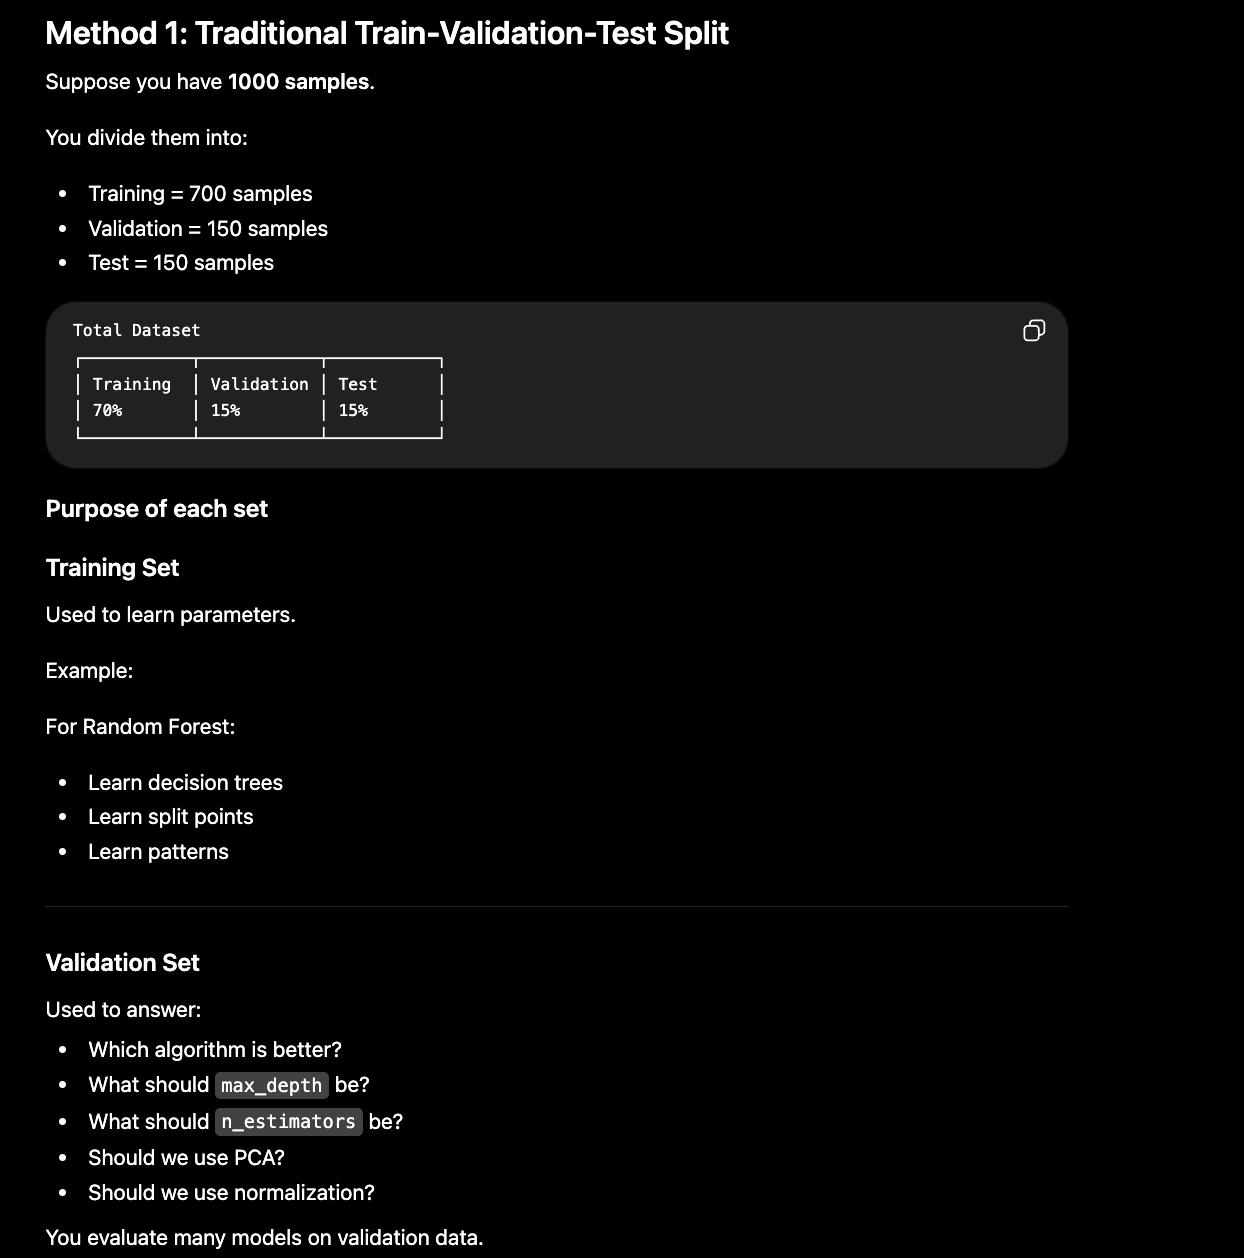

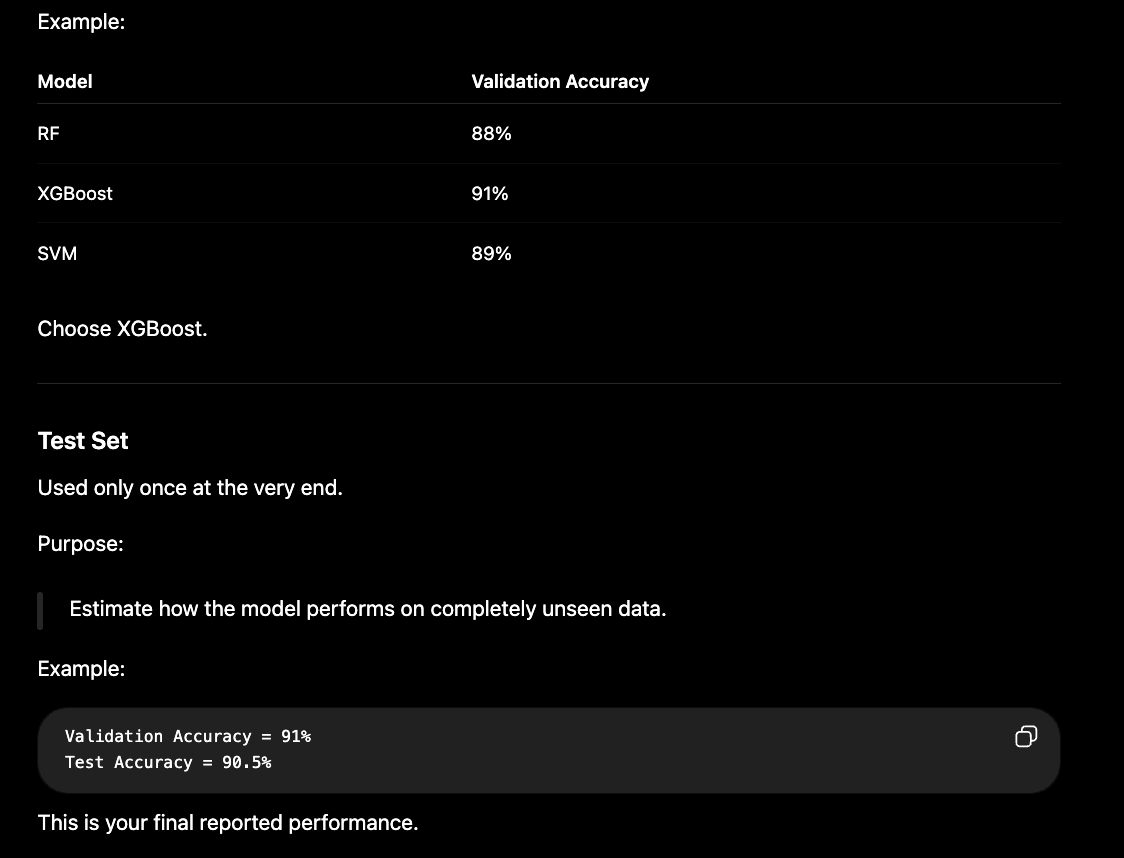

In [ ]:
## first we train different models on training set 
## then we evaluate each model on validation set to pick the best model

## or first we train different version (diff hyperparameters) of same model on training set
## then we evaluate each version of the same model on validation set to pick best hyperparameters

In [8]:
## spse there 100 samples 
## you train on 70 samples and then you evaulate your model on 15 samples of validationset and check which model performs the best

In [ ]:
# Problem with Validation Split

# Suppose your validation set accidentally contains:

# easier examples
# harder examples
# more class imbalance

# Then performance estimate becomes unreliable.

# This means your estimate depends heavily on which samples happened to fall into validation.

# This is exactly why Cross Validation was invented.

Method 1: Train + Validation + Test

Suppose we have:

Train = 70%

Validation = 15%

Test = 15%

and we want to tune:

max_depth

for a Random Forest.

In [30]:
# Method 1: Single Validation Split

# Suppose you have:

# 70% Training
# 15% Validation
# 15% Test

# Step 1: Train different models and then validate on validation set(15%)
# Model	Validation Accuracy
# Random Forest	88%
# XGBoost	90%
# SVM	87%

# You select: XGBoost

# Step 2: Tune hyperparameters of XGBoost

# Now you try:
# max_depth	learning_rate	Validation Accuracy
# 3	          0.1	           88%
# 5	          0.1	           91%
# 7	          0.1	           89%

# You choose:

# max_depth = 5
# learning_rate = 0.1
# Again, this decision is based on the same 15% validation set.

# Step 3: Evaluate on test set

# After selecting:

# Model = XGBoost
# max_depth = 5
# learning_rate = 0.1

# you train on: Training + Validation = 85%

# and evaluate once on:

# Test = 15%

In [31]:
# Train candidate models on 70%
# ↓
# Evaluate on 15% validation
# ↓
# Choose best model and hyperparameters from 15% validation set 
# ↓
# Retrain the chosen model on 85%
# ↓
# Evaluate once on the 15% test set

In [ ]:
# Training = 70%
# Validation = 15%
# Test = 15%
# Step 1: Train candidate models on the 70% training set
# RF.fit(X_train, y_train)
# XGB.fit(X_train, y_train)
# SVM.fit(X_train, y_train)

# At this point:

# Random Forest learns its parameters from the 70%.
# XGBoost learns its parameters from the 70%.
# SVM learns its parameters from the 70%.

# Step 2: Evaluate on the 15% validation set
# rf_score = accuracy_score(y_val, RF.predict(X_val))
# xgb_score = accuracy_score(y_val, XGB.predict(X_val))
# svm_score = accuracy_score(y_val, SVM.predict(X_val))

# Suppose:

# Model	Validation Accuracy
# RF	88%
# XGB	91%
# SVM	87%

# You choose:

# XGBoost
# Step 3: Hyperparameter tuning (still using the same 70% + 15%)

# Now you try multiple versions of XGBoost:

# Hyperparameters	Validation Accuracy
# depth=3	          89%
# depth=5	          92%
# depth=7	          90%

# Choose: depth = 5

# Notice: During this entire process:

# Training always happens on the original 70%.
# Validation always happens on the same 15%.

# You may train dozens or hundreds of models during this stage.

# Step 4: Final retraining on 85%

# Once all decisions are made:

# Best model = XGBoost
# Best hyperparameters = depth=5

# Now you combine:  70% training + 15% validation = 85%

# and train one final model: final_model.fit(X_train_val, y_train_val)

# This is done because the validation data is no longer needed for decision-making, so we can use it to give the model more data to learn from.

# Step 5: Evaluate once on the test set
# pred = final_model.predict(X_test)

# accuracy_score(y_test, pred)

# Suppose:

# Test Accuracy = 90.8%

# This is your final reported result.

In [47]:
import numpy as np
import pandas as pd
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/Datasets/creditcard.csv')
df=df.sample(10000)

In [48]:
from sklearn.model_selection import train_test_split

X=df.drop('Class',axis=1)
y=df['Class']
# Step 1: Split into temporary train (85%) and final test (15%)
X_tmp,X_test,y_tmp,y_test=train_test_split(X,y,test_size=0.15,random_state=42)


# Step 2: Split temporary train into final train (70%) and validation (15%)
# 0.15 is roughly 17.65% of 0.85 but overall 15 percent of whole dataset
## 70 percent training + 15 percent validation + 15 percent test 
X_train,X_val,y_train,y_val=train_test_split(X_tmp,y_tmp,test_size=0.1765,random_state=42)



In [45]:
# Alternative: Clean 60 / 20 / 20 Math
# If you prefer a 60% Train / 20% Validation / 20% Test ratio,
#  the math is much simpler because exactly one-quarter (25%) of your remaining 80% dataset
#  will equal 20%.
# 

'''
from sklearn.model_selection import train_test_split

 Step 1: Isolate the test set (20%)
 X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

 Step 2: Extract validation (20% of total, which is 25% of the remaining 80%)
 X_train, X_val, y_train, y_val = train_test_split(
     X_tmp, y_tmp, test_size=0.25, random_state=42
 )
 '''

'\nfrom sklearn.model_selection import train_test_split\n\n Step 1: Isolate the test set (20%)\n X_tmp, X_test, y_tmp, y_test = train_test_split(\n    X, y, test_size=0.20, random_state=42\n)\n\n Step 2: Extract validation (20% of total, which is 25% of the remaining 80%)\n X_train, X_val, y_train, y_val = train_test_split(\n     X_tmp, y_tmp, test_size=0.25, random_state=42\n )\n '

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

model1=RandomForestClassifier(max_depth=10,n_estimators=1,random_state=42)
model2=RandomForestClassifier(max_depth=20,n_estimators=10,random_state=42)
model1.fit(X_train,y_train)
model2.fit(X_train,y_train)
pred1 = model1.predict(X_val)
pred2= model2.predict(X_val)
score1 = accuracy_score(y_val, pred1)
score2= accuracy_score(y_val,pred2)
print(score1)
print(score2)

## we choose 

## we see validation score 2 is better therefore we choose model2

## similarly we can check for different hyperparameters of the same model or different models also

0.9980013324450366
0.9986675549633578


In [ ]:
## Now retrain the best model on entire Training dataset (70+15=85%)

model2.fit(X_tmp,y_tmp)
accuracy_score(model2.predict(X_test),y_test)


0.9986666666666667

## Method 2: Cross Validation


Training and Validation together

In [ ]:

# # Instead of one validation set:
# # Train = 80%
# # Validation = 20%

# # we repeatedly create validation sets.

# # Suppose dataset has 1000 rows.

# # For 5-fold CV:

# # Fold1 = 200 samples
# # Fold2 = 200 samples
# # Fold3 = 200 samples
# # Fold4 = 200 samples
# # Fold5 = 200 samples

# Iteration 1
# Validation: Fold1

# Training: Fold2 + Fold3 + Fold4 + Fold5
# V T T T T


# Iteration 2
# Validation: Fold2
# Training: Fold1 + Fold3 + Fold4 + Fold5
# T V T T T


# Iteration 3
# T T V T T

# Iteration 4
# T T T V T

# Iteration 5
# T T T T V
# Result

# Every sample:

# used for training 4 times
# used for validation 1 time

# This gives a much more reliable estimate.

# Example:

# Fold1 Accuracy = 89%
# Fold2 Accuracy = 91%
# Fold3 Accuracy = 90%
# Fold4 Accuracy = 88%
# Fold5 Accuracy = 92%

# Average:

# Mean Accuracy = 90%



# But where is the Test Set? This is the important part.
#Cross Validation replaces only the validation set, not the test set.

# The proper workflow is:
# Entire Dataset
# │
# ├── Training + Validation (80%)
# │
# └── Test Set (20%)

# Then perform cross validation only on the 80%.
# 80% Data
# │
# ├── Fold1
# ├── Fold2
# ├── Fold3
# ├── Fold4
# └── Fold5
# The remaining 20% test data is untouched.

# Real Example

# Suppose:

# 1000 samples total

# Step 1:

# Train+Validation = 800
# Test = 200
# ┌───────────────────────┬─────────┐
# │ Train + Validation    │ Test    │
# │ 800                   │ 200     │
# └───────────────────────┴─────────┘


# Step 2:

# Perform 5-fold CV on the 800 samples.

# Iteration 1:

# Validation = 160
# Training = 640

# Iteration 2:

# Validation = 160
# Training = 640

# and so on.


# Step 3:

# Suppose cross validation results are:

# 89%
# 90%
# 88%
# 91%
# 90%

# Mean:

# 89.6%

# You decide:

# Random Forest
# max_depth=10
# n_estimators=200



# Step 4:  Train final model on all 800 samples.

# model.fit(X_train_val, y_train_val)

# Now the model uses the full 800 samples.


# Step 5:  Evaluate once on test set.
# pred = model.predict(X_test)
# accuracy_score(y_test, pred)

# Result: Test Accuracy = 89.2%

# This is the number you report in papers, reports, and resumes.

In [29]:
 ## Where does Cross Validation fit?

 ## Instead of using a single validation score:
# n_estimators=200, max_depth=10
# Validation Accuracy = 91%

# we use multiple validation scores:

# Fold 1 = 90%
# Fold 2 = 92%
# Fold 3 = 91%
# Fold 4 = 89%
# Fold 5 = 91%

# Average: 90.6%

# Now compare another parameter combination:
# n_estimators=500, max_depth=15

# Fold 1 = 91%
# Fold 2 = 90%
# Fold 3 = 92%
# Fold 4 = 90%
# Fold 5 = 89%

# Average: 90.4%

# Since:

# 90.6% > 90.4%

# we select:

# n_estimators = 200
# max_depth = 10

## Why not include test set inside cross validation?

Because then the model indirectly sees the test data.
Example:

You test:

Random Forest

XGBoost

SVM

and choose the best based on test accuracy.

Now your test set influenced model selection.

The test set is no longer "unseen".

This causes data leakage.

## Cross Validation

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Step 1: Separate test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 2: Cross validation on training data only
model1 = RandomForestClassifier(max_depth=10,n_estimators=1,random_state=42)
model2 = RandomForestClassifier(max_depth=1,n_estimators=10,random_state=42)

scores1 = cross_val_score(
    model1,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

scores2= cross_val_score(
    model2,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Scores of model1:", scores1 )
print("CV Scores of model2:", scores2 )

CV Scores of model1: [0.99895833 0.99895833 0.99895833 1.         1.        ]
CV Scores of model2: [0.99895833 1.         0.99895833 1.         0.99895833]


In [ ]:
print("Mean CV Accuracy of model1:", scores1.mean())
print("Mean CV Accuracy of model2:", scores2.mean())

## we choose model 2 because it has better validation 

Mean CV Accuracy of model1: 0.9993749999999999
Mean CV Accuracy of model2: 0.999375


In [27]:
# Step 3: Train on full training data
model2.fit(X_train, y_train)

# Step 4: Final evaluation
test_accuracy = model2.score(X_test, y_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9966666666666667


In [28]:
# Dataset
#    ↓
# Train-Test Split
#    ↓
# Cross Validation on Train
#    ↓
# Choose Best Model
#    ↓
# Train on Entire Training Data
#    ↓
# Evaluate Once on Test Data

## Why use cross validation during tuning?

Because performance from a single validation split may be misleading.

In [81]:
# Common Evaluation Metrics

# Classification:
# accuracy
# precision
# recall
# f1
# roc_auc

# Regression:
# r2
# neg_mean_squared_error
# neg_mean_absolute_error
# neg_root_mean_squared_error

## 1. Manual Search

In [89]:
from sklearn.metrics import accuracy_score
depths=[3,5,10,15,20]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
best_model=RandomForestClassifier()
best_score=0
for depth in depths:
    model=RandomForestClassifier(max_depth=depth)
    score=cross_val_score(
        model,
        X_train,
        y_train,
        cv=5 ## no of cross folds
    )
    if(best_score==None or best_score < score.mean()):
        best_score=score.mean()
        best_model=model
    print(depth,score.mean())

print(best_score)

best_model.fit(X_train,y_train)


3 0.9416666666666667
5 0.95
10 0.9416666666666668
15 0.9416666666666667
20 0.95
0.95


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [90]:
y_pred=best_model.predict(X_test)
print(accuracy_score(y_pred,y_test))

1.0


## Advantages

Easy to understand.

Good for learning.

## Disadvantages

Slow.

Not scalable.

## 2.Grid Search

Exhaustively tries every combination.

Example Search Space:

n_estimators = [100,200,500]

max_depth = [5,10,20]

criterion = ['gini','entropy']

Total combinations:

3 × 3 × 2 = 18 models

In [ ]:
# Generate all hyperparameter combinations
# ↓
# Perform k-fold CV for each combination
# ↓
# Compute mean score
# ↓
# Choose best combination
# ↓
# Retrain best model on entire training data
# ↓
# Store it inside grid.best_estimator_

In [94]:
import numpy as np
import pandas as pd
df=pd.read_csv('/Users/priyanshugupta/Desktop/scikit learn/Datasets/creditcard.csv')
df=df.sample(10000)
from sklearn.model_selection import train_test_split

X=df.drop('Class',axis=1)
y=df['Class']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)


In [98]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid={
    "max_depth":[5,10,20],
    'n_estimators':[100,200,500],
    "criterion":['gini','entropy']
}

grid=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    cv=5,
    refit=True
)

grid.fit(X_train,y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ......criterion=gini, max_depth=5, n_estimators=100; total time=   1.5s
[CV] END ......criterion=gini, max_depth=5, n_estimators=100; total time=   1.5s
[CV] END ......criterion=gini, max_depth=5, n_estimators=100; total time=   1.6s
[CV] END ......criterion=gini, max_depth=5, n_estimators=100; total time=   1.6s
[CV] END ......criterion=gini, max_depth=5, n_estimators=100; total time=   1.7s
[CV] END ......criterion=gini, max_depth=5, n_estimators=200; total time=   3.0s
[CV] END ......criterion=gini, max_depth=5, n_estimators=200; total time=   3.1s
[CV] END ......criterion=gini, max_depth=5, n_estimators=200; total time=   3.1s
[CV] END ......criterion=gini, max_depth=5, n_estimators=200; total time=   3.4s
[CV] END ......criterion=gini, max_depth=5, n_estimators=200; total time=   3.4s
[CV] END .....criterion=gini, max_depth=10, n_estimators=100; total time=   1.5s
[CV] END .....criterion=gini, max_depth=10, n_es

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

<!-- verbose=0: Silent mode. No progress bars, logs, or metrics are shown.

verbose=1: Normal mode. Standard logging output, metrics, or animated progress visualizers are displayed.

verbose=2: Compact/Detailed mode. In Keras, it yields exactly one plain text summary line per epoch instead of a progress bar. In other tools, it acts as a deep logging tier. -->

## estimator

estimator=RandomForestClassifier()

This tells GridSearch:

"The algorithm I want to tune is Random Forest."

GridSearchCV itself is not a model.

It is a wrapper around another model.

For example:

GridSearchCV(RandomForestClassifier())

GridSearchCV(XGBClassifier())

GridSearchCV(SVC())

GridSearchCV(LogisticRegression())

are all valid.

In [97]:
# Since there are:

# 18 combinations

# and

# 5 folds

# total model trainings are:

# 18 × 5 = 90

# So GridSearch trains 90 different Random Forest models.

## 1 model lets take example max_depth=5, n_estimators=100 we take 5 models of random forest with same hyperparameters as n_dep=5 and n_est=100
## we train those 5 models of same hyperparameters on 5 folds and get their mean score
## this accounts for our 1 combination but still we use 5 diff models of same hyperparameter

## scoring

scoring='f1'

Determines which metric should be optimized.

GridSearch chooses the hyperparameters that maximize this metric.

Examples:

scoring='accuracy'

scoring='precision'

scoring='recall'

scoring='f1'

scoring='roc_auc'

## verbose

verbose=0

No messages.

verbose=1

Shows progress:

Fitting 5 folds for each of 18 candidates,
totalling 90 fits
verbose=2

Shows each fit separately.

verbose=3

Shows even more detailed information.

## n_jobs

n_jobs=-1

Determines CPU cores used.

n_jobs=1

Use one CPU core.

n_jobs=4

Use four CPU cores.

n_jobs=-1

Use all available CPU cores.

## What happens during grid.fit()

In [ ]:
# Internally:

# Combination 1
# RF(
#     n_estimators=100,
#     max_depth=5,
#     criterion='gini'
# )

# 5-fold CV performed.

# Mean F1 stored.

# Combination 2
# RF(
#     n_estimators=100,
#     max_depth=5,
#     criterion='entropy'
# )

# 5-fold CV performed.

# Mean F1 stored.

# This continues for all 18 combinations.

# GridSearch creates a table internally:

# n_estimators	max_depth	criterion	Mean F1
# 100	               5	       gini	    0.82
# 100	               5	       entropy	0.83
# 100	               10	       gini	    0.86
# 100	               10	       entropy	0.85
# 200	               10	        gini	0.88
# 500	               20	        entropy	0.87

# The highest score wins.

In [ ]:
# Does grid contain the best model?

# Yes.

# After training:

# grid.best_estimator_

# returns the best trained model.

# Example:

# RandomForestClassifier(
#     n_estimators=200,
#     max_depth=10,
#     criterion='gini'
# )


# Best hyperparameters
# grid.best_params_

# Example:

# {
#     'n_estimators':200,
#     'max_depth':10,
#     'criterion':'gini'
# }


# Best score
# grid.best_score_

# Example:

# 0.8812

# This is the mean cross-validation F1 score.

In [ ]:
# Predict directly

# Since GridSearch stores the best model:

# pred = grid.predict(X_test)

# works directly.

# Equivalent to:

# best_model = grid.best_estimator_

# pred = best_model.predict(X_test)

In [ ]:
# Does GridSearch retrain the best model?

# Yes.

# By default:

# refit=True

# which means:

# After finding the best hyperparameters, 
# GridSearch trains one final model on the entire training dataset using those best hyperparameters.

# So after:

# grid.fit(X_train,y_train)

# you already have a fully trained best model available in:

# grid.best_estimator_

# No additional .fit() is required unless you intentionally set:

# refit=False

## Results

In [101]:
grid.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [102]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}

In [103]:
grid.best_score_

np.float64(0.54)

## Computational Complexity

Suppose:

10 values for parameter A

10 values for parameter B

10 values for parameter C

Total:

1000 models (combinations)

If:

cv = 5

Total training operations:

5000 model fits

## 3.Randomized Search

Instead of trying all combinations:

Grid Search: Try everything

Random Search: Try random combinations

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions={ "n_estimators":[100,200,300,500,700,1000], "max_depth":[5,10,20,30,40], "min_samples_split":[2,5,10] }

random_search=RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2,
    n_iter=10
)

random_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   1.6s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   1.6s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   1.7s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   1.6s
[CV] END max_depth=10, min_samples_split=5, n_estimators=100; total time=   1.8s
[CV] END max_depth=10, min_samples_split=10, n_estimators=300; total time=   4.7s
[CV] END max_depth=10, min_samples_split=10, n_estimators=300; total time=   4.7s
[CV] END max_depth=10, min_samples_split=10, n_estimators=300; total time=   4.8s
[CV] END max_depth=10, min_samples_split=10, n_estimators=300; total time=   4.9s
[CV] END max_depth=10, min_samples_split=10, n_estimators=300; total time=   5.2s
[CV] END max_depth=10, min_samples_split=2, n_estimators=300; total time=   4.8s
[CV] END max_depth=10, min_samples_split=2,

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defa

## Important Parameter: n_iter

Most important parameter.

Controls: Number of random combinations tested.

Example: n_iter=50

means: Try only 50 combinations.

## Advantages
Much faster than Grid Search.
Works better in high dimensions.

## Disadvantages
Can miss optimal values.

In [106]:
# Grid Search vs Random Search
# Grid Search	              Random Search
# Tries all combinations	 Tries random combinations
# Slow	                     Fast
# Finds optimum in grid	     Approximate optimum
# Small search spaces	     Large search spaces

In [107]:
random_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [108]:
random_search.best_params_

{'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 5}

In [109]:
random_search.best_score_

np.float64(0.999)

## 4.HalvedSearchCV

HalvingGridSearchCV is an optimization of GridSearchCV.

The basic idea is:

Do not spend a lot of computation on obviously bad hyperparameter combinations.

Instead:

Give every candidate a small amount of resources.

Remove the worst candidates.

Give more resources to the surviving candidates.

Repeat until only a few good candidates remain.

This is why it is called Successive Halving.

In [110]:
# Why GridSearch can be expensive
# Suppose:
# param_grid = { "n_estimators":[100,200,500], "max_depth":[5,10,20],"criterion":["gini","entropy"]}

# Number of combinations: 3 × 3 × 2 = 18

# With:  cv=5

# total model trainings become: 18 × 5 = 90 fits

# GridSearch treats every candidate equally.  Even terrible hyperparameters receive the 
# same amount of computation as excellent ones.


# Example:
# Hyperparameters	F1 Score
# depth=5	        0.88
# depth=10	        0.90
# depth=1000	    0.55

# GridSearch still spends full resources evaluating depth=1000. Halving Search Idea
# Suppose we start with 100 hyperparameter combinations.


# Round 1: Train all 100 models using a small amount of data.

# Example: Use only 10% of training data

# Results:
# Candidate	Score
# 1	        0.91
# 2	        0.88
# 3	        0.52
# ...	    ...
# Keep only the best 50. Remove the worst 50.
# 100 → 50


# Round 2, Now train only those 50 candidates.
# This time use more resources.
# Example: Use 20% of training data
# Evaluate again.
# Keep best 25.
# 50 → 25


# Round 3
# Train only 25 candidates.
# Use even more resources.

# Example:
# Use: 40% of data
# Keep best 12.
# 25 → 12


# Round 4
# Train 12 candidates.
# Use: 80% of data
# Keep best 6.

# Round 5
# Train remaining 6 candidates using full resources.
# Choose best candidate.

# Visual Example
# Imagine these scores after each round:

# Round 1
# A 90
# B 89
# C 88
# D 87
# E 60
# F 55
# G 52
# H 50

# Remove:  E F G H

# Round 2
# Remaining: A B C D

# Scores:
# A 91
# B 90
# C 88
# D 84

# Remove: C D

# Round 3  Remaining:  A B

# Scores:
# A 92
# B 90

# Winner:

# A


In [111]:
# What is the "resource"?
# By default: resource = number of training samples
# Meaning: Round 1 may train using:

# 1000 samples

# Round 2:  2000 samples

# Round 3: 4000 samples

# and so on.

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

param_grid={ "n_estimators":[100,200,300,500,700,1000], "max_depth":[5,10,20,30,40], "min_samples_split":[2,5,10] }

search=HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5
)

search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (string) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_samples'
,"max_resources max_resources: int, default='auto'The maximum amount of resource that any candidate is allowed to usefor a given iteration. By default, this is set to ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",'auto'
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='exhaust'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",'exhaust'
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... note:: Due to implementation details, the folds produced by `cv` must be the same across multiple calls to `cv.split()`. For built-in `scikit-learn` iterators, this can be achieved by deactivating shuffling (`shuffle=False`), or by setting the `cv`'s

In [113]:
model=search.best_estimator_
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",700
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [116]:
search.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 700}

In [117]:
search.best_score_

np.float64(0.9987397605545054)

## Advantages

Faster than Grid Search.
Uses fewer resources.

## HalvingRandomSearchCV

In [118]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
param_distributions={ "n_estimators":[100,200,300,500,700,1000], "max_depth":[5,10,20,30,40], "min_samples_split":[2,5,10] }

search=HalvingRandomSearchCV(
estimator=RandomForestClassifier(random_state=42),
cv=5,
param_distributions=param_distributions
)

search.fit(X_train,y_train)

/Users/priyanshugupta/Desktop/scikit learn/.venv/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 90 is smaller than n_iter=400. Running 90 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_candidates n_candidates: ""exhaust"" or int, default=""exhaust""The number of candidate parameters to sample, at the firstiteration. Using 'exhaust' will sample enough candidates so that thelast iteration uses as many resources as possible, based on`min_resources`, `max_resources` and `factor`. In this case,`min_resources` cannot be 'exhaust'.",'exhaust'
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_samples'
,"max_resources max_resources: int, default='auto'The maximum number of resources that any candidate is allowed to usefor a given iteration. By default, this is set ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",'auto'
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='smallest'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming. 'exhaust' isn't available when `n_candidates='exhaust'`.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",'smallest'
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or an iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or m

## Why use Pipeline with GridSearchCV?

To avoid data leakage.

## Why use StratifiedKFold for classification?

To preserve class distribution in every fold.

In [114]:
# Rule of Thumb
# Dataset Size	   Recommended Method
# Small	            Grid Search
# Medium	        Random Search
# Large	            Bayesian Optimization
# Very Large	    Optuna

In [115]:
# Most Common Production Setup
# Pipeline
#     ↓
# StratifiedKFold
#     ↓
# RandomizedSearchCV
#     ↓
# Best Model

# This workflow is one of the most common approaches used in production machine learning systems.

## Bayesian Optimization (Optuna)

Bayesian Optimization is one of the most powerful hyperparameter tuning methods because it tries to answer:

"Based on the results I have already seen, where should I search next?" This is very different from Grid Search and Random Search.

## Comparison of Search Strategies

Suppose the true relationship between max_depth and F1 score looks like this:

max_depth

3   -> 0.75

5   -> 0.82

10  -> 0.91

15  -> 0.93

20  -> 0.92

25  -> 0.88

30  -> 0.83

The optimum is near:

max_depth ≈ 15

## Grid Search

Tests everything:

3,5,10,15,20,25,30


Pros:

Guaranteed to check all specified values.

Cons:

Wasteful.

## Random Search

Maybe chooses: 5,30,7,18,4,25


Pros: Faster than Grid Search.

Cons: Still random. and May miss good regions completely.


## Bayesian Optimization

Starts with a few random points:

5  -> 0.82

20 -> 0.92

30 -> 0.83

Now it thinks:

The best score so far is near 20. The region around 15-20 looks promising. Let's explore there.

So next it tries:

15 -> 0.93

17 -> 0.94

16 -> 0.935

It spends most of its effort near promising areas. This is why it is called intelligent search

In [119]:
# Scikit-Learn does not provide Bayesian Optimization directly.

# Popular libraries:

# Optuna
# Hyperopt
# Scikit-Optimize

# Idea
# Instead of random guessing:
# Use previous results
# ↓
# Predict promising regions
# ↓
# Search intelligently

In [126]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

def objective(trial): ## "Given a set of hyperparameters, tell me how good they are."
    ## Input: trial represents one experiment.
    model=RandomForestClassifier(
        n_estimators=trial.suggest_int( 
            'n_estimators', ## Choose an integer value between 100 and 1000.
            100,           ## example: Trial 1 → 153, Trial 2 → 847, Trial 3 → 621
            1000
        ),
        max_depth=trial.suggest_int(
            "max_depth", ## choose an integer value between 3 and 30
            3,            ## example: Trial 1 → 5, Trial 2 → 18, Trial 3 → 12
            30
        ),
        criterion=trial.suggest_categorical(
            "criterion", ## choose categorical variable either gini or entropy 
            ["gini","entropy"]
        )
    )
      #Construct Model # Suppose Optuna chooses: n_estimators = 400 max_depth = 12
    score=cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1'
    ).mean()
    
    return score

study=optuna.create_study(
    ## A study stores: 1. all trials 2.all scores 3.best hyperparameters. 4.optimization history
    direction='maximize'
)

# direction='maximize'
# Means:  Higher score is better.
# Used for: Accuracy, F1, Precision, Recall, ROC-AUC

# If minimizing:
# direction='minimize'
# Examples: RMSE, MAE, Log Loss

study.optimize(
    objective,
    n_trials=50 ## Run objective function 50 times.
)   
## Each trial performs a 5 fold cv --> 50 trials * 5 folds = 250 model trainings

[I 2026-07-12 00:19:35,918] A new study created in memory with name: no-name-f3290d15-17db-4323-9ff4-6f3cd114a161
[I 2026-07-12 00:20:16,251] Trial 0 finished with value: 0.5 and parameters: {'n_estimators': 963, 'max_depth': 21, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5.
[I 2026-07-12 00:20:57,645] Trial 1 finished with value: 0.5 and parameters: {'n_estimators': 987, 'max_depth': 26, 'criterion': 'entropy'}. Best is trial 0 with value: 0.5.
[I 2026-07-12 00:21:25,241] Trial 2 finished with value: 0.5 and parameters: {'n_estimators': 560, 'max_depth': 9, 'criterion': 'gini'}. Best is trial 0 with value: 0.5.
[I 2026-07-12 00:21:56,850] Trial 3 finished with value: 0.5 and parameters: {'n_estimators': 635, 'max_depth': 11, 'criterion': 'gini'}. Best is trial 0 with value: 0.5.
[I 2026-07-12 00:22:34,862] Trial 4 finished with value: 0.5 and parameters: {'n_estimators': 765, 'max_depth': 10, 'criterion': 'gini'}. Best is trial 0 with value: 0.5.
[I 2026-07-12 00:22:47,034

In [ ]:
# What happens internally?

# Trial 1 Optuna starts randomly:
# n_estimators=150
# max_depth=4
# Result: F1 = 0.79


# Trial 2
# Random again:
# n_estimators=900
# max_depth=25
# Result: F1 = 0.88


# Trial 3
# Random:
# n_estimators=700
# max_depth=18

# Result: F1 = 0.91

# Now Optuna starts learning.
# It notices:

# Large depth performs better.
# Very small depth performs poorly.



# Trial 4
# Instead of random:
# n_estimators=750
# max_depth=17

# Result: 0.92


# Trial 5
# n_estimators=720
# max_depth=16
# Result:  0.924


# Trial 6
# n_estimators=690
# max_depth=15
# Result:  0.926

In [127]:
study.best_params

{'n_estimators': 963, 'max_depth': 21, 'criterion': 'entropy'}

In [128]:
study.best_value

0.5

In [129]:
study.best_trial


# Contains:

# parameters
# score
# trial number
# additional metadata

# Visualizing Search

# Suppose the trials looked like:

# Trial	n_estimators	max_depth	F1
# 1	150	4	0.79
# 2	900	25	0.88
# 3	700	18	0.91
# 4	750	17	0.92
# 5	720	16	0.924
# 6	690	15	0.926

# Notice how search gradually moves toward better regions.

FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.5], datetime_start=datetime.datetime(2026, 7, 12, 0, 19, 35, 919693), datetime_complete=datetime.datetime(2026, 7, 12, 0, 20, 16, 250926), params={'n_estimators': 963, 'max_depth': 21, 'criterion': 'entropy'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'max_depth': IntDistribution(high=30, log=False, low=3, step=1), 'criterion': CategoricalDistribution(choices=('gini', 'entropy'))}, trial_id=0, value=None)

## Why is it called Bayesian Optimization?

Internally it builds a probabilistic model:

Hyperparameters-> Expected Performance

It estimates:

If I try max_depth=16,
I expect F1 ≈ 0.925

and

If I try max_depth=5,
I expect F1 ≈ 0.80

Then it chooses the next trial using these probability estimates.


The exact mathematics involves:

1.Gaussian Processes

2.Tree Parzen Estimators (Optuna default)

3.Acquisition Functions

but for practical ML work you can think of it as:
"Use previous experiments to predict where good hyperparameters are likely to be."

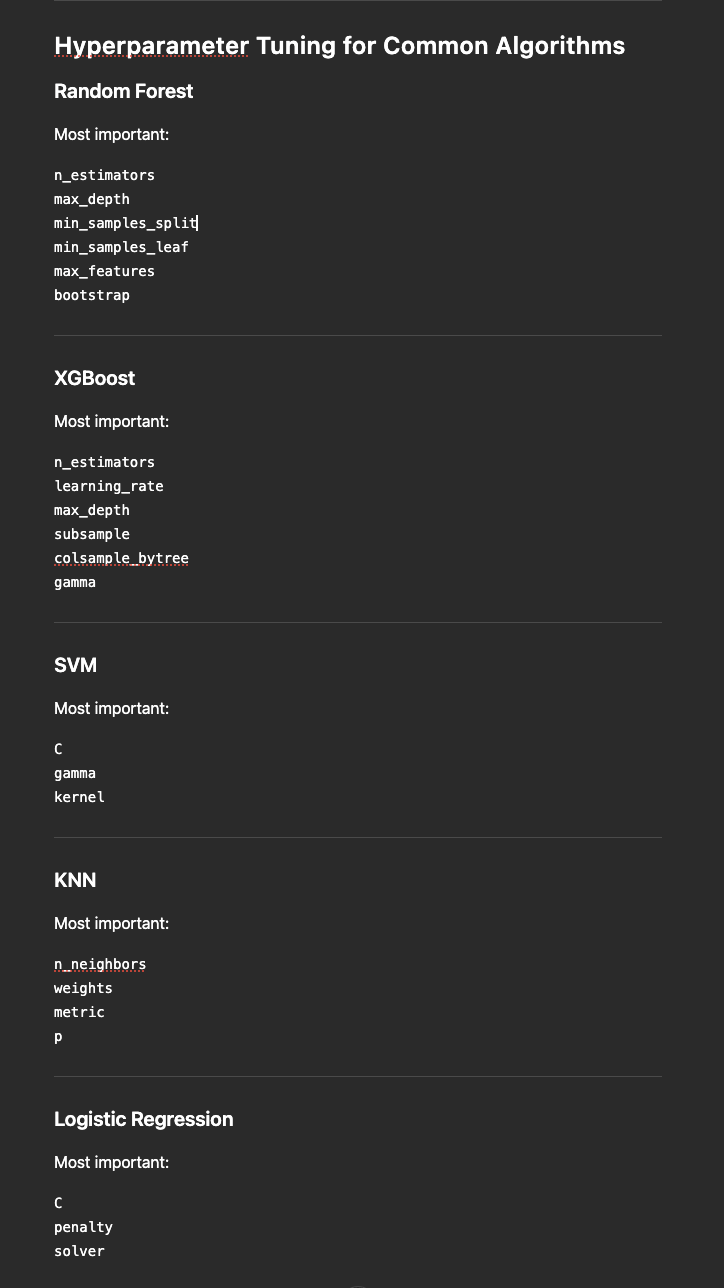

In [130]:
# Pipelines with Hyperparameter Tuning

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipe=Pipeline(
    [
        ('scaler',StandardScaler()),
        ('model',SVC())
    ]
)
params = {
   'model__C':[0.1,1,10],
  'model__gamma':[0.01,0.1,1]
}

grid = GridSearchCV(
   pipe,
   params,
   cv=5
)

grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

## StratifiedKFold

## Problem with normal KFold

Normal K-Fold splits data randomly.

Suppose:

1000 samples- 900 negative, 100 positive i.e 10% positive class.


Fold 1:

190 negative and 10 positive

Fold 2:

200 negative and 0 positive

Fold 3:

170 negative and 30 positive

Some folds become highly imbalanced.

This makes validation scores unstable.

## StratifiedKFold Solution

It preserves class proportions in every fold.

Dataset:

900 negative and 100 positive i.e 10% positives.

With 5 folds:

Each fold gets approximately:

180 negative and 20 positive

Every fold has the same class distribution.

Visual:

Fold1 -> 180 N + 20 P

Fold2 -> 180 N + 20 P

Fold3 -> 180 N + 20 P

Fold4 -> 180 N + 20 P

Fold5 -> 180 N + 20 P

In [134]:
from sklearn.model_selection import StratifiedKFold
skf=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for train_idx,val_idx in skf.split(X,y):
    X_train_fold=X.iloc[train_idx]
    X_val_fold=X.iloc[val_idx]

    y_train_fold=y.iloc[train_idx]
    y_val_fold=y.iloc[val_idx]
    
